In [1]:
import pandas as pd
import numpy as np
import json
import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'png'  # статический рендер: plotly-графики видны на GitHub
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)

COLORS = ['#6366f1', '#8b5cf6', '#a78bfa', '#c4b5fd', '#ddd6fe', '#ede9fe']
ACCENT = '#6366f1'

In [2]:
# Загрузка данных
raw_events = pd.read_csv('events_raw.csv')
raw_events['created_at'] = pd.to_datetime(raw_events['created_at'])

users = pd.read_csv('users.csv')
users_activity = pd.read_csv('users_activity.csv')
users_activity['first_event_at'] = pd.to_datetime(users_activity['first_event_at'])
users_activity['last_event_at'] = pd.to_datetime(users_activity['last_event_at'])

results = pd.read_csv('results_rows.csv')
results['created_at'] = pd.to_datetime(results['created_at'])

habits = pd.read_csv('habits_rows.csv')
habits['created_at'] = pd.to_datetime(habits['created_at'])

progress = pd.read_csv('progress_rows.csv')

events_summary = pd.read_csv('events_summary.csv')

# Парсинг params_json
raw_events['params'] = raw_events['params_json'].apply(lambda x: json.loads(x) if pd.notna(x) else {})

print(f"Всего событий: {len(raw_events)}")
print(f"Уникальных пользователей (события): {raw_events['user_id'].nunique()}")
print(f"Зарегистрированных пользователей: {len(users)}")
print(f"Период: {raw_events['created_at'].min().date()} — {raw_events['created_at'].max().date()}")
print(f"\nТипы событий ({raw_events['event'].nunique()}):")
print(raw_events['event'].value_counts().to_string())

Всего событий: 1171
Уникальных пользователей (события): 57
Зарегистрированных пользователей: 9
Период: 2026-03-19 — 2026-03-26

Типы событий (20):
event
page_view                              530
quiz_answer                            311
quiz_start                              58
result_view                             38
dashboard_view                          35
quiz_complete                           33
recommendations_view                    31
habit_toggle                            28
recommendations_open_from_result        22
tracker_view                            17
sign_in_success                         10
habit_add                               10
sign_up_error                            9
dashboard_open                           8
sign_up_success                          7
recommendations_open_from_dashboard      7
feedback_submit                          5
pdf_export                               5
sign_in_error                            4
habit_delete                  

## 1. Воронка конверсии

Основной флоу: **Главная → Квиз → Результат → Рекомендации → Регистрация → Трекер привычек**

Sign-up происходит после просмотра рекомендаций, но возможна точка входа и в начале.

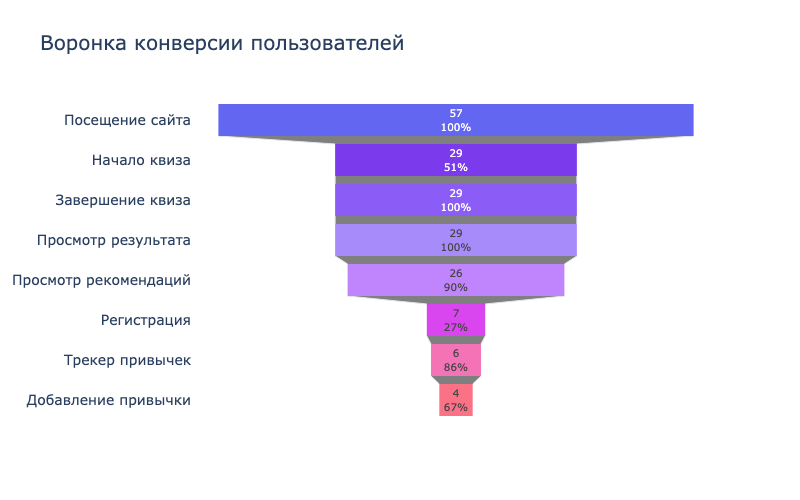


Детализация воронки:
                 step  users  pct_total  pct_prev
      Посещение сайта     57      100.0     100.0
         Начало квиза     29       50.9      50.9
     Завершение квиза     29       50.9     100.0
  Просмотр результата     29       50.9     100.0
Просмотр рекомендаций     26       45.6      89.7
          Регистрация      7       12.3      26.9
      Трекер привычек      6       10.5      85.7
  Добавление привычки      4        7.0      66.7


In [3]:
# Воронка: считаем уникальных пользователей на каждом этапе
funnel_steps = [
    ('Посещение сайта', 'page_view'),
    ('Начало квиза', 'quiz_start'),
    ('Завершение квиза', 'quiz_complete'),
    ('Просмотр результата', 'result_view'),
    ('Просмотр рекомендаций', 'recommendations_view'),
    ('Регистрация', 'sign_up_success'),
    ('Трекер привычек', 'tracker_view'),
    ('Добавление привычки', 'habit_add'),
]

funnel_data = []
for label, event in funnel_steps:
    n_users = raw_events[raw_events['event'] == event]['user_id'].nunique()
    funnel_data.append({'step': label, 'users': n_users})

funnel_df = pd.DataFrame(funnel_data)
funnel_df['pct_total'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['pct_prev'] = [100.0] + (funnel_df['users'].iloc[1:].values / funnel_df['users'].iloc[:-1].values * 100).round(1).tolist()

fig = go.Figure(go.Funnel(
    y=funnel_df['step'],
    x=funnel_df['users'],
    textinfo='value+percent previous',
    textposition='inside',
    marker=dict(
        color=['#6366f1', '#7c3aed', '#8b5cf6', '#a78bfa', '#c084fc', '#d946ef', '#f472b6', '#fb7185'],
    ),
    connector=dict(line=dict(color='#e2e8f0', width=1)),
))

fig.update_layout(
    title=dict(text='Воронка конверсии пользователей', font=dict(size=20)),
    font=dict(size=14),
    height=500,
    width=800,
    plot_bgcolor='white',
)
fig.show()

print("\nДетализация воронки:")
print(funnel_df.to_string(index=False))

## 2. Санки-диаграмма переходов между событиями

Визуализация реальных путей пользователей: откуда пришли → куда пошли. Показывает альтернативные маршруты и точки выхода.

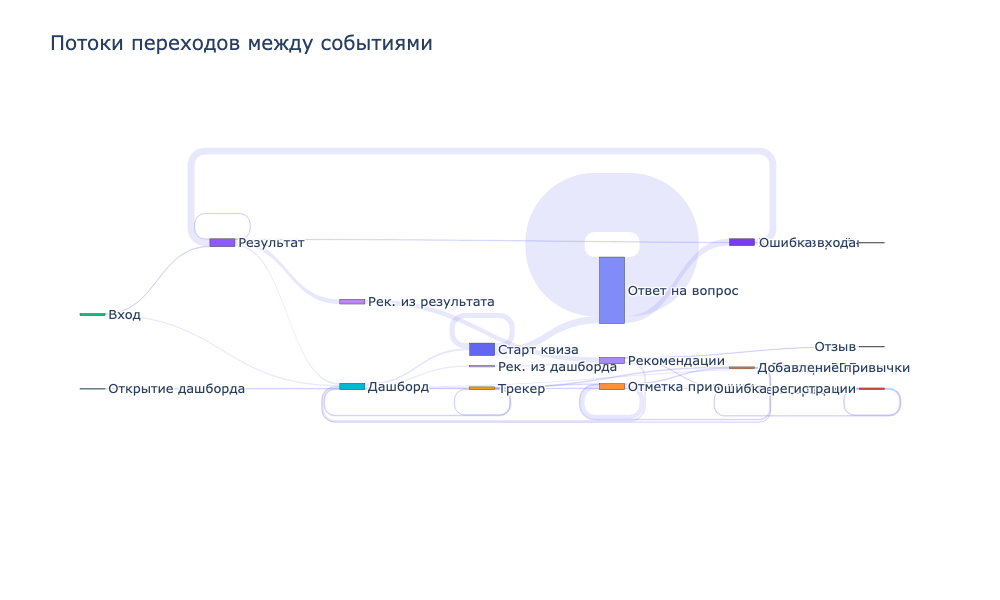

In [4]:
# Санки-диаграмма: переходы между последовательными событиями пользователя
events_sorted = raw_events.sort_values(['user_id', 'created_at']).copy()

# Убираем дублирующиеся page_view, оставляем значимые события
key_events = events_sorted[events_sorted['event'] != 'page_view'].copy()

# Добавляем следующее событие пользователя
key_events['next_event'] = key_events.groupby('user_id')['event'].shift(-1)
transitions = key_events.dropna(subset=['next_event'])

# Считаем переходы
transition_counts = transitions.groupby(['event', 'next_event']).size().reset_index(name='count')
transition_counts = transition_counts[transition_counts['count'] >= 2]  # фильтр шума

# Строим Sankey
all_events = list(set(transition_counts['event'].tolist() + transition_counts['next_event'].tolist()))
event_idx = {e: i for i, e in enumerate(all_events)}

# Красивые названия
label_map = {
    'quiz_start': 'Старт квиза',
    'quiz_answer': 'Ответ на вопрос',
    'quiz_complete': 'Квиз завершён',
    'result_view': 'Результат',
    'recommendations_view': 'Рекомендации',
    'recommendations_open_from_result': 'Рек. из результата',
    'recommendations_open_from_dashboard': 'Рек. из дашборда',
    'sign_up_success': 'Регистрация',
    'sign_up_error': 'Ошибка регистрации',
    'sign_in_success': 'Вход',
    'sign_in_error': 'Ошибка входа',
    'tracker_view': 'Трекер',
    'habit_add': 'Добавление привычки',
    'habit_toggle': 'Отметка привычки',
    'habit_delete': 'Удаление привычки',
    'dashboard_view': 'Дашборд',
    'dashboard_open': 'Открытие дашборда',
    'feedback_submit': 'Отзыв',
    'pdf_export': 'Экспорт PDF',
}

labels = [label_map.get(e, e) for e in all_events]

node_colors = []
color_map = {
    'quiz_start': '#6366f1', 'quiz_answer': '#818cf8', 'quiz_complete': '#7c3aed',
    'result_view': '#8b5cf6', 'recommendations_view': '#a78bfa',
    'recommendations_open_from_result': '#c084fc',
    'recommendations_open_from_dashboard': '#d8b4fe',
    'sign_up_success': '#22c55e', 'sign_up_error': '#ef4444',
    'sign_in_success': '#10b981', 'sign_in_error': '#f87171',
    'tracker_view': '#f59e0b', 'habit_add': '#f97316', 'habit_toggle': '#fb923c',
    'habit_delete': '#fbbf24',
    'dashboard_view': '#06b6d4', 'dashboard_open': '#22d3ee',
    'feedback_submit': '#ec4899', 'pdf_export': '#14b8a6',
}
for e in all_events:
    node_colors.append(color_map.get(e, '#94a3b8'))

fig = go.Figure(go.Sankey(
    node=dict(
        pad=20, thickness=25,
        label=labels,
        color=node_colors,
    ),
    link=dict(
        source=[event_idx[r['event']] for _, r in transition_counts.iterrows()],
        target=[event_idx[r['next_event']] for _, r in transition_counts.iterrows()],
        value=transition_counts['count'].tolist(),
        color='rgba(99, 102, 241, 0.15)',
    ),
))

fig.update_layout(
    title=dict(text='Потоки переходов между событиями', font=dict(size=20)),
    font=dict(size=13),
    height=600, width=1000,
)
fig.show()

## 3. Когортный анализ удержания (Retention)

Группируем пользователей по дню первого визита. Считаем, сколько из них вернулись на Day 1, Day 2 и т.д.

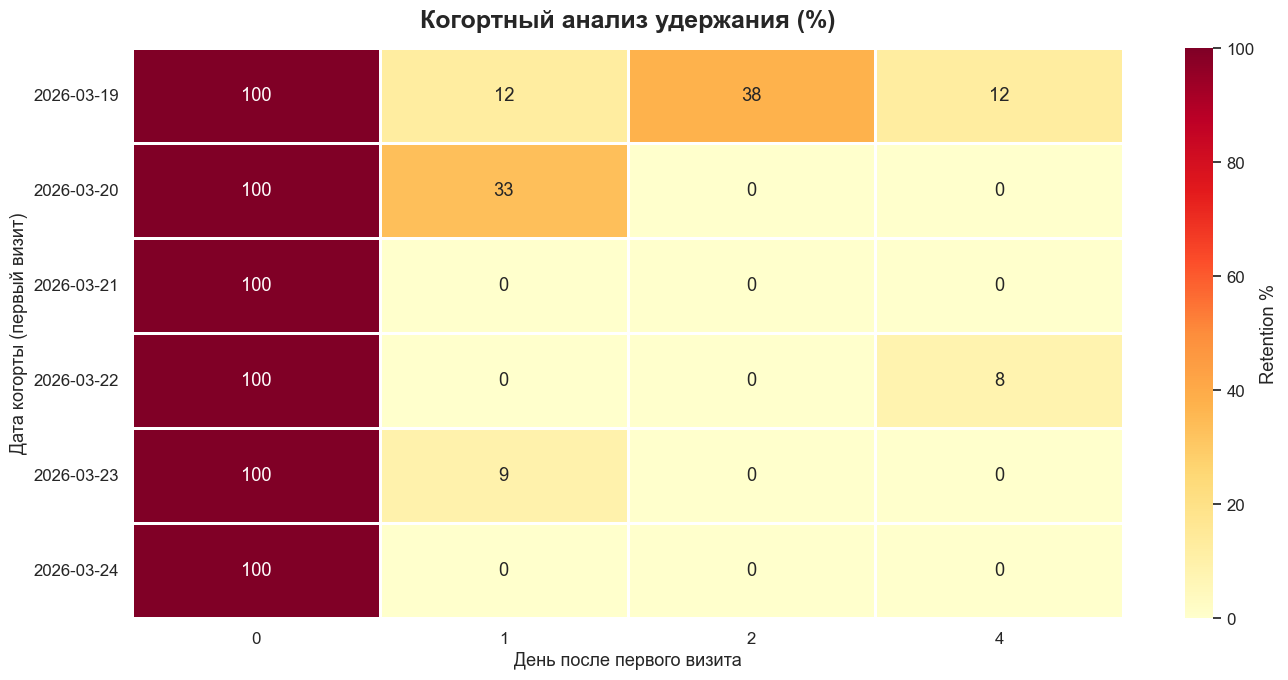

Средний retention по дням:
  Day 0: 100.0%
  Day 1: 9.2%
  Day 2: 6.2%
  Day 4: 3.5%


In [5]:
# Когортный retention
events_with_date = raw_events.copy()
events_with_date['date'] = events_with_date['created_at'].dt.date

# Первый визит каждого пользователя
first_visit = events_with_date.groupby('user_id')['date'].min().reset_index()
first_visit.columns = ['user_id', 'cohort_date']

# Объединяем
events_cohort = events_with_date.merge(first_visit, on='user_id')
events_cohort['day_n'] = (pd.to_datetime(events_cohort['date']) - pd.to_datetime(events_cohort['cohort_date'])).dt.days

# Строим retention-матрицу
cohort_sizes = events_cohort.groupby('cohort_date')['user_id'].nunique().reset_index()
cohort_sizes.columns = ['cohort_date', 'cohort_size']

retention_raw = events_cohort.groupby(['cohort_date', 'day_n'])['user_id'].nunique().reset_index()
retention_raw.columns = ['cohort_date', 'day_n', 'users']
retention_raw = retention_raw.merge(cohort_sizes, on='cohort_date')
retention_raw['retention'] = (retention_raw['users'] / retention_raw['cohort_size'] * 100).round(1)

# Pivot для heatmap
retention_pivot = retention_raw.pivot(index='cohort_date', columns='day_n', values='retention').fillna(0)
# Ограничиваем до 7 дней
retention_pivot = retention_pivot[[c for c in retention_pivot.columns if c <= 7]]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    retention_pivot,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=1, linecolor='white',
    cbar_kws={'label': 'Retention %'},
    ax=ax,
)
ax.set_title('Когортный анализ удержания (%)', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('День после первого визита', fontsize=13)
ax.set_ylabel('Дата когорты (первый визит)', fontsize=13)
ax.set_yticklabels([str(d) for d in retention_pivot.index], rotation=0)
plt.tight_layout()
plt.show()

# Средний retention по дням
avg_retention = retention_pivot.mean().round(1)
print("Средний retention по дням:")
for day, val in avg_retention.items():
    print(f"  Day {day}: {val}%")

## 4. Анализ квиза

- Распределение баллов (violin plot)
- Heatmap ответов по вопросам
- Связь балла квиза с дальнейшей вовлечённостью

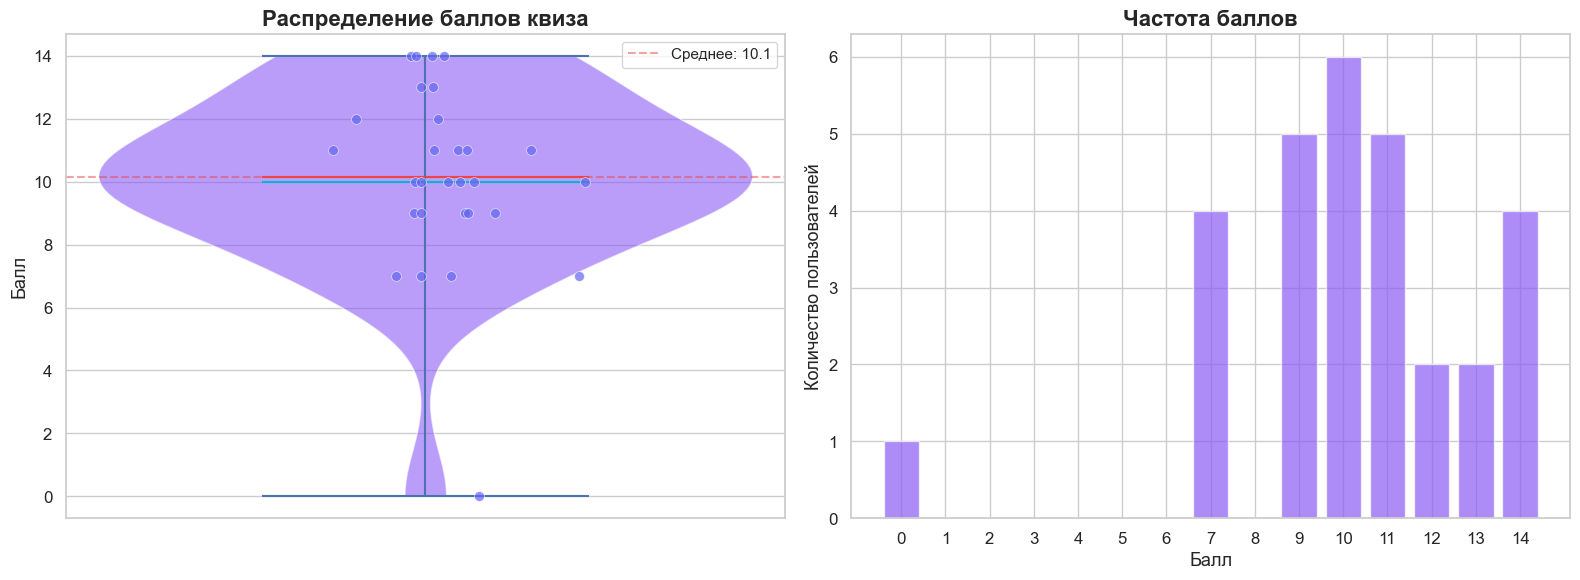

Статистика баллов: среднее=10.1, медиана=10.0, мин=0, макс=14


In [6]:
# 4a. Распределение баллов квиза (violin + strip)
quiz_scores = raw_events[raw_events['event'] == 'quiz_complete'].copy()
quiz_scores['score'] = quiz_scores['params'].apply(lambda x: x.get('score', None))
quiz_scores = quiz_scores.dropna(subset=['score'])
quiz_scores['score'] = quiz_scores['score'].astype(int)

# Берём последний результат каждого пользователя
last_scores = quiz_scores.sort_values('created_at').groupby('user_id').last().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin plot
parts = axes[0].violinplot(last_scores['score'], positions=[0], showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#8b5cf6')
    pc.set_alpha(0.6)
parts['cmeans'].set_color('#ef4444')
parts['cmedians'].set_color('#06b6d4')

# Добавляем точки
axes[0].scatter(
    np.random.normal(0, 0.04, len(last_scores)),
    last_scores['score'],
    color='#6366f1', alpha=0.7, s=50, zorder=5, edgecolors='white', linewidth=0.5
)
axes[0].set_title('Распределение баллов квиза', fontsize=16, fontweight='bold')
axes[0].set_ylabel('Балл', fontsize=13)
axes[0].set_xticks([])
axes[0].axhline(y=last_scores['score'].mean(), color='#ef4444', linestyle='--', alpha=0.5, label=f"Среднее: {last_scores['score'].mean():.1f}")
axes[0].legend(fontsize=11)

# Гистограмма с KDE-подобным эффектом
score_counts = last_scores['score'].value_counts().sort_index()
axes[1].bar(score_counts.index, score_counts.values, color='#8b5cf6', alpha=0.7, edgecolor='white', width=0.8)
axes[1].set_title('Частота баллов', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Балл', fontsize=13)
axes[1].set_ylabel('Количество пользователей', fontsize=13)
axes[1].set_xticks(range(0, 15))

plt.tight_layout()
plt.show()

print(f"Статистика баллов: среднее={last_scores['score'].mean():.1f}, медиана={last_scores['score'].median():.1f}, "
      f"мин={last_scores['score'].min()}, макс={last_scores['score'].max()}")

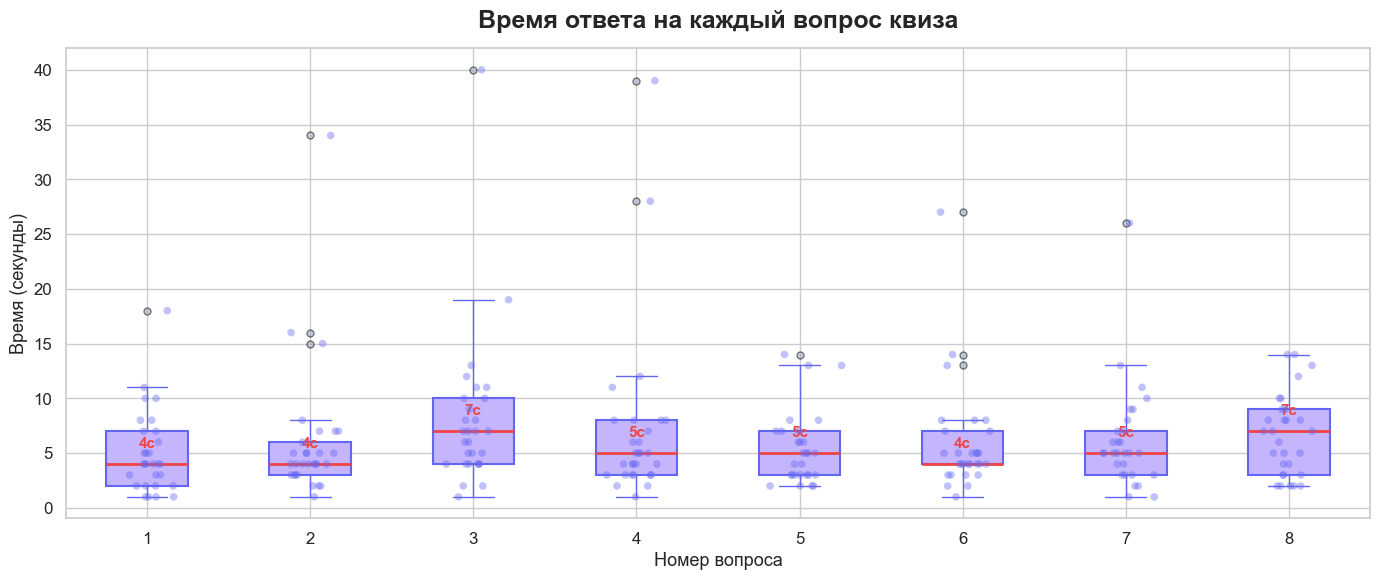

Самый долгий вопрос: №3 (медиана 7с) — вероятно, требует больше размышлений
Самый быстрый вопрос: №1 (медиана 4с) — очевидный ответ для большинства


In [7]:
# 4b. Время на каждый вопрос квиза
quiz_answers = raw_events[raw_events['event'] == 'quiz_answer'].sort_values(['user_id', 'created_at']).copy()
quiz_answers['question'] = quiz_answers['params'].apply(lambda x: x.get('question'))

# Дедупликация: первый ответ на каждый вопрос
quiz_answers = quiz_answers.drop_duplicates(subset=['user_id', 'question'], keep='first')

# Время между ответами
quiz_answers['prev_time'] = quiz_answers.groupby('user_id')['created_at'].shift(1)
quiz_answers['time_spent'] = (quiz_answers['created_at'] - quiz_answers['prev_time']).dt.total_seconds()

# Для первого вопроса — время от quiz_start
qs = raw_events[raw_events['event'] == 'quiz_start'].sort_values('created_at').drop_duplicates('user_id', keep='first')
qs_map = dict(zip(qs['user_id'], qs['created_at']))
mask = quiz_answers['time_spent'].isna()
quiz_answers.loc[mask, 'time_spent'] = quiz_answers.loc[mask].apply(
    lambda r: (r['created_at'] - qs_map.get(r['user_id'], r['created_at'])).total_seconds(), axis=1
)

# Фильтр выбросов (>60с — отвлёкся)
qa_clean = quiz_answers[(quiz_answers['time_spent'] > 0) & (quiz_answers['time_spent'] <= 60)]

# Box plot + strip plot
fig, ax = plt.subplots(figsize=(14, 6))

bp = ax.boxplot(
    [qa_clean[qa_clean['question'] == q]['time_spent'].values for q in sorted(qa_clean['question'].unique())],
    positions=sorted(qa_clean['question'].unique()),
    widths=0.5, patch_artist=True,
    boxprops=dict(facecolor='#c4b5fd', edgecolor='#6366f1', linewidth=1.5),
    medianprops=dict(color='#ef4444', linewidth=2),
    whiskerprops=dict(color='#6366f1'), capprops=dict(color='#6366f1'),
    flierprops=dict(marker='o', markerfacecolor='#94a3b8', markersize=5, alpha=0.5),
)

# Точки поверх
for q in sorted(qa_clean['question'].unique()):
    data = qa_clean[qa_clean['question'] == q]['time_spent']
    ax.scatter(
        np.random.normal(q, 0.08, len(data)), data,
        color='#6366f1', alpha=0.4, s=30, zorder=5, edgecolors='none'
    )

# Медианные подписи
medians = qa_clean.groupby('question')['time_spent'].median()
for q, med in medians.items():
    ax.text(q, med + 1.5, f'{med:.0f}с', ha='center', fontsize=11, fontweight='bold', color='#ef4444')

ax.set_title('Время ответа на каждый вопрос квиза', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Номер вопроса', fontsize=13)
ax.set_ylabel('Время (секунды)', fontsize=13)
ax.set_xticks(sorted(qa_clean['question'].unique()))
plt.tight_layout()
plt.show()

# Выводы
slowest = medians.idxmax()
fastest = medians.idxmin()
print(f"Самый долгий вопрос: №{int(slowest)} (медиана {medians[slowest]:.0f}с) — вероятно, требует больше размышлений")
print(f"Самый быстрый вопрос: №{int(fastest)} (медиана {medians[fastest]:.0f}с) — очевидный ответ для большинства")

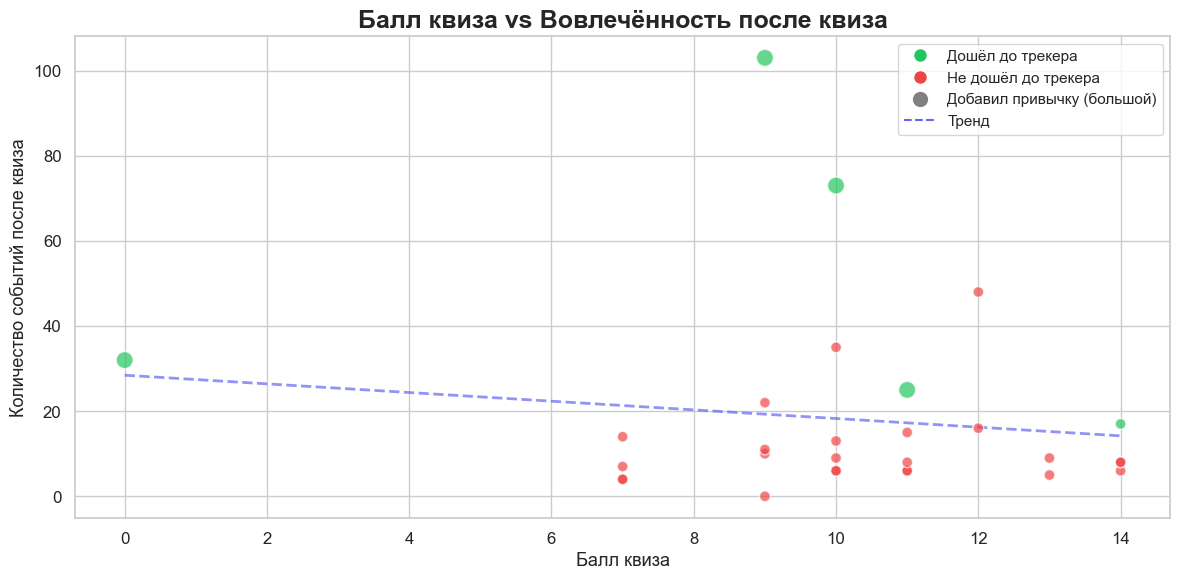

Корреляция балла и пост-квиз активности: -0.132
Дошли до трекера: 5 из 29 (17%)
Добавили привычку: 4 из 29 (14%)


In [8]:
# 4c. Связь балла квиза с дальнейшей вовлечённостью
# Для каждого пользователя: балл квиза vs количество событий после квиза
quiz_complete_events = raw_events[raw_events['event'] == 'quiz_complete'].sort_values('created_at').groupby('user_id').first().reset_index()
quiz_complete_events['score'] = quiz_complete_events['params'].apply(lambda x: x.get('score', 0))

engagement = []
for _, row in quiz_complete_events.iterrows():
    uid = row['user_id']
    quiz_time = row['created_at']
    post_quiz = raw_events[(raw_events['user_id'] == uid) & (raw_events['created_at'] > quiz_time)]
    engagement.append({
        'user_id': uid,
        'score': row['score'],
        'post_quiz_events': len(post_quiz),
        'reached_tracker': 'tracker_view' in post_quiz['event'].values,
        'added_habit': 'habit_add' in post_quiz['event'].values,
    })

engagement_df = pd.DataFrame(engagement)

fig, ax = plt.subplots(figsize=(12, 6))

scatter_colors = engagement_df['reached_tracker'].map({True: '#22c55e', False: '#ef4444'})
scatter_markers = engagement_df['added_habit'].map({True: 150, False: 60})

ax.scatter(
    engagement_df['score'], engagement_df['post_quiz_events'],
    c=scatter_colors, s=scatter_markers, alpha=0.7,
    edgecolors='white', linewidth=1, zorder=5,
)

# Трендовая линия
z = np.polyfit(engagement_df['score'], engagement_df['post_quiz_events'], 1)
p = np.poly1d(z)
x_line = np.linspace(engagement_df['score'].min(), engagement_df['score'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#6366f1', alpha=0.7, linewidth=2, label='Тренд')

ax.set_title('Балл квиза vs Вовлечённость после квиза', fontsize=18, fontweight='bold')
ax.set_xlabel('Балл квиза', fontsize=13)
ax.set_ylabel('Количество событий после квиза', fontsize=13)

# Легенда
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#22c55e', markersize=10, label='Дошёл до трекера'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ef4444', markersize=10, label='Не дошёл до трекера'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12, label='Добавил привычку (большой)'),
    Line2D([0], [0], linestyle='--', color='#6366f1', label='Тренд'),
]
ax.legend(handles=legend_elements, fontsize=11)
plt.tight_layout()
plt.show()

corr = engagement_df['score'].corr(engagement_df['post_quiz_events'])
print(f"Корреляция балла и пост-квиз активности: {corr:.3f}")
print(f"Дошли до трекера: {engagement_df['reached_tracker'].sum()} из {len(engagement_df)} ({engagement_df['reached_tracker'].mean()*100:.0f}%)")
print(f"Добавили привычку: {engagement_df['added_habit'].sum()} из {len(engagement_df)} ({engagement_df['added_habit'].mean()*100:.0f}%)")

## 5. Сегментация пользователей

Кластеризация по поведенческим паттернам: глубина прохождения воронки, количество событий, возвраты.

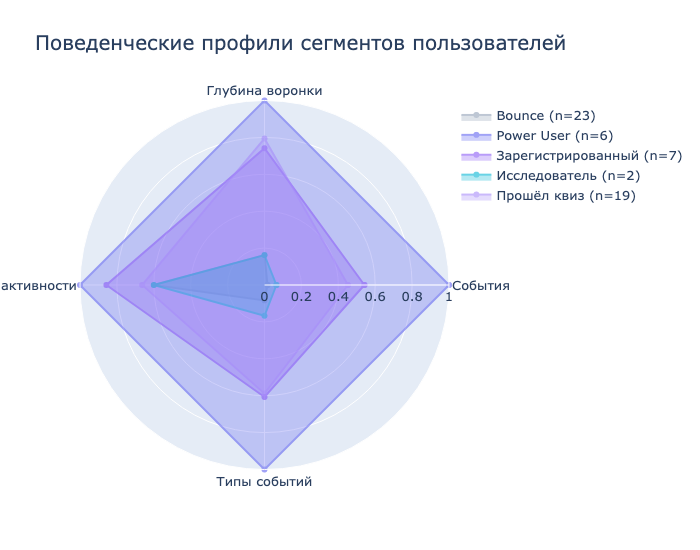

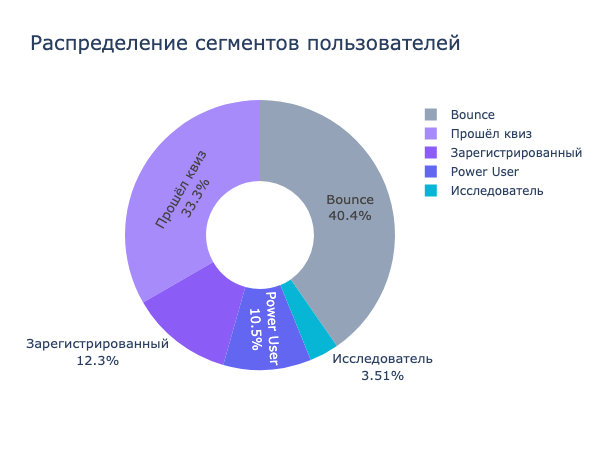


Сегменты:
  Bounce: 23 (40%)
  Прошёл квиз: 19 (33%)
  Зарегистрированный: 7 (12%)
  Power User: 6 (11%)
  Исследователь: 2 (4%)


In [9]:
# Профиль каждого пользователя
user_profiles = []
for uid in raw_events['user_id'].unique():
    user_events = raw_events[raw_events['user_id'] == uid]
    event_set = set(user_events['event'])
    
    # Глубина воронки (0-7)
    funnel_events = ['page_view', 'quiz_start', 'quiz_complete', 'result_view',
                     'recommendations_view', 'sign_up_success', 'tracker_view', 'habit_add']
    depth = sum(1 for e in funnel_events if e in event_set)
    
    # Количество уникальных дней
    n_days = user_events['created_at'].dt.date.nunique()
    
    user_profiles.append({
        'user_id': uid,
        'total_events': len(user_events),
        'funnel_depth': depth,
        'n_days': n_days,
        'took_quiz': 'quiz_complete' in event_set,
        'signed_up': 'sign_up_success' in event_set,
        'used_tracker': 'tracker_view' in event_set,
        'n_event_types': user_events['event'].nunique(),
    })

profiles_df = pd.DataFrame(user_profiles)

# Сегменты на основе поведения
def assign_segment(row):
    if row['used_tracker']:
        return 'Power User'
    elif row['signed_up']:
        return 'Зарегистрированный'
    elif row['took_quiz']:
        return 'Прошёл квиз'
    elif row['total_events'] > 1:
        return 'Исследователь'
    else:
        return 'Bounce'

profiles_df['segment'] = profiles_df.apply(assign_segment, axis=1)

# Radar chart по сегментам
segment_stats = profiles_df.groupby('segment').agg({
    'total_events': 'mean',
    'funnel_depth': 'mean',
    'n_days': 'mean',
    'n_event_types': 'mean',
}).reset_index()

# Нормализация для radar chart (0-1)
metrics = ['total_events', 'funnel_depth', 'n_days', 'n_event_types']
metric_labels = ['События', 'Глубина воронки', 'Дни активности', 'Типы событий']

for m in metrics:
    max_val = segment_stats[m].max()
    segment_stats[f'{m}_norm'] = segment_stats[m] / max_val if max_val > 0 else 0

fig = go.Figure()

segment_colors = {
    'Power User': '#6366f1',
    'Зарегистрированный': '#8b5cf6',
    'Прошёл квиз': '#a78bfa',
    'Исследователь': '#06b6d4',
    'Bounce': '#94a3b8',
}

for _, row in segment_stats.iterrows():
    values = [row[f'{m}_norm'] for m in metrics]
    values.append(values[0])  # замыкаем
    
    fig.add_trace(go.Scatterpolar(
        r=values,
        theta=metric_labels + [metric_labels[0]],
        fill='toself',
        name=f"{row['segment']} (n={len(profiles_df[profiles_df['segment']==row['segment']])})",
        line=dict(color=segment_colors.get(row['segment'], '#94a3b8')),
        opacity=0.6,
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=dict(text='Поведенческие профили сегментов пользователей', font=dict(size=20)),
    font=dict(size=13),
    height=550, width=700,
    showlegend=True,
)
fig.show()

# Пирог сегментов
segment_counts = profiles_df['segment'].value_counts()
fig2 = go.Figure(go.Pie(
    labels=segment_counts.index,
    values=segment_counts.values,
    hole=0.4,
    marker=dict(colors=[segment_colors.get(s, '#94a3b8') for s in segment_counts.index]),
    textinfo='label+percent',
    textfont=dict(size=13),
))
fig2.update_layout(
    title=dict(text='Распределение сегментов пользователей', font=dict(size=20)),
    height=450, width=600,
)
fig2.show()

print("\nСегменты:")
for seg in segment_counts.index:
    n = segment_counts[seg]
    pct = n / len(profiles_df) * 100
    print(f"  {seg}: {n} ({pct:.0f}%)")

## 6. Активность во времени

- Stacked area chart — события по дням в разбивке по типам
- Heatmap «день недели x час» — когда пользователи наиболее активны

/var/folders/mq/hdkb64ls4fd_fzqmcy2rzpn00000gn/T/ipykernel_59509/3368520738.py:57: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image('activity.png', width=900, height=520, scale=2)


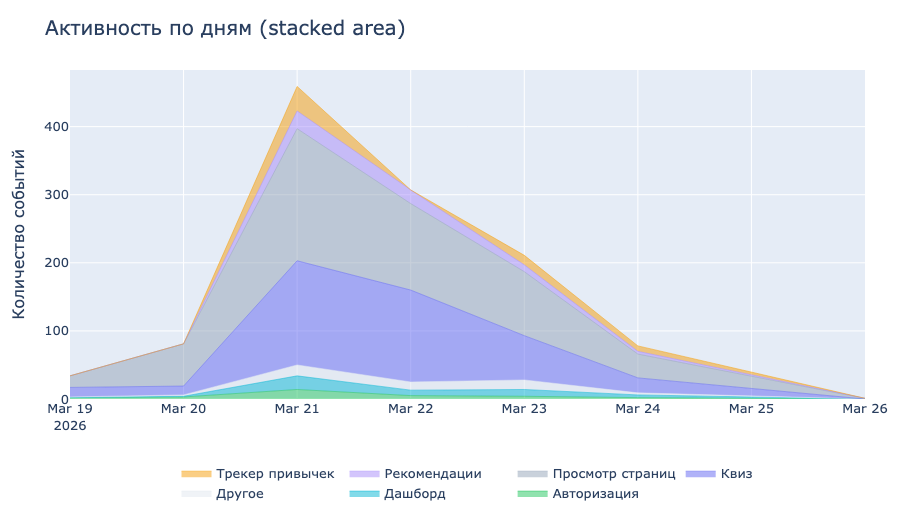

In [10]:
# 6a. Stacked area chart — события по дням
raw_events['date'] = raw_events['created_at'].dt.date

# Группируем по основным категориям
def categorize_event(event):
    if 'quiz' in event:
        return 'Квиз'
    elif 'sign' in event:
        return 'Авторизация'
    elif 'habit' in event or 'tracker' in event:
        return 'Трекер привычек'
    elif 'recommendation' in event:
        return 'Рекомендации'
    elif event in ('dashboard_view', 'dashboard_open'):
        return 'Дашборд'
    elif event == 'page_view':
        return 'Просмотр страниц'
    else:
        return 'Другое'

raw_events['category'] = raw_events['event'].apply(categorize_event)

daily_cats = raw_events.groupby(['date', 'category']).size().reset_index(name='count')
daily_pivot = daily_cats.pivot(index='date', columns='category', values='count').fillna(0)

cat_colors = {
    'Просмотр страниц': '#94a3b8',
    'Квиз': '#6366f1',
    'Авторизация': '#22c55e',
    'Рекомендации': '#a78bfa',
    'Трекер привычек': '#f59e0b',
    'Дашборд': '#06b6d4',
    'Другое': '#e2e8f0',
}

fig = go.Figure()
for cat in daily_pivot.columns:
    fig.add_trace(go.Scatter(
        x=daily_pivot.index, y=daily_pivot[cat],
        mode='lines', stackgroup='one',
        name=cat,
        line=dict(color=cat_colors.get(cat, '#94a3b8'), width=0.5),
    ))

fig.update_layout(
    title=dict(text='Активность по дням (stacked area)', font=dict(size=20)),
    xaxis_title='', yaxis_title='Количество событий',
    font=dict(size=13),
    height=520, width=900,
    margin=dict(l=70, r=30, t=70, b=110),
    legend=dict(
        orientation='h',
        yanchor='top', y=-0.18,
        xanchor='center', x=0.5,
    ),
)
fig.write_image('activity.png', width=900, height=520, scale=2)
fig.show()

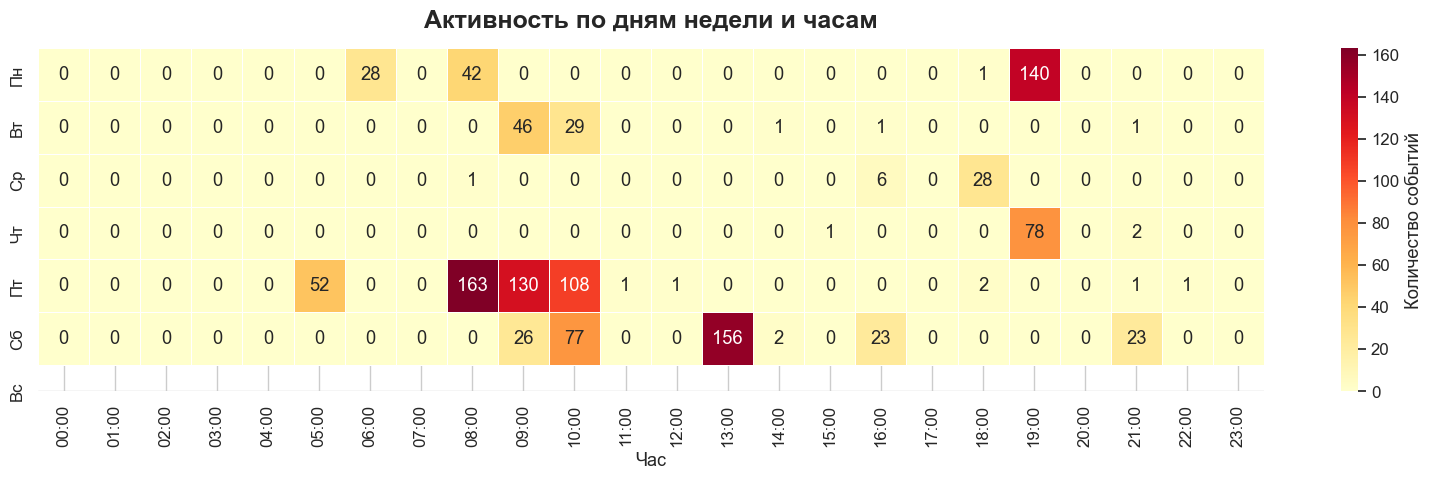

In [11]:
# 6b. Heatmap «день недели × час»
raw_events['hour'] = raw_events['created_at'].dt.hour
raw_events['weekday'] = raw_events['created_at'].dt.dayofweek

weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

heatmap_data = raw_events.groupby(['weekday', 'hour']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot(index='weekday', columns='hour', values='count').fillna(0)

# Заполняем пропущенные часы
for h in range(24):
    if h not in heatmap_pivot.columns:
        heatmap_pivot[h] = 0
heatmap_pivot = heatmap_pivot[sorted(heatmap_pivot.columns)]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_pivot, annot=True, fmt='.0f',
    cmap='YlOrRd', linewidths=0.5, linecolor='white',
    xticklabels=[f'{h:02d}:00' for h in range(24)],
    yticklabels=weekday_names,
    cbar_kws={'label': 'Количество событий'},
    ax=ax,
)
ax.set_title('Активность по дням недели и часам', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Час', fontsize=13)
ax.set_ylabel('', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Трекер привычек — анализ приверженности

- Процент выполнения по каждой привычке
- Heatmap активности трекинга по дням
- Динамика трекинга привычек

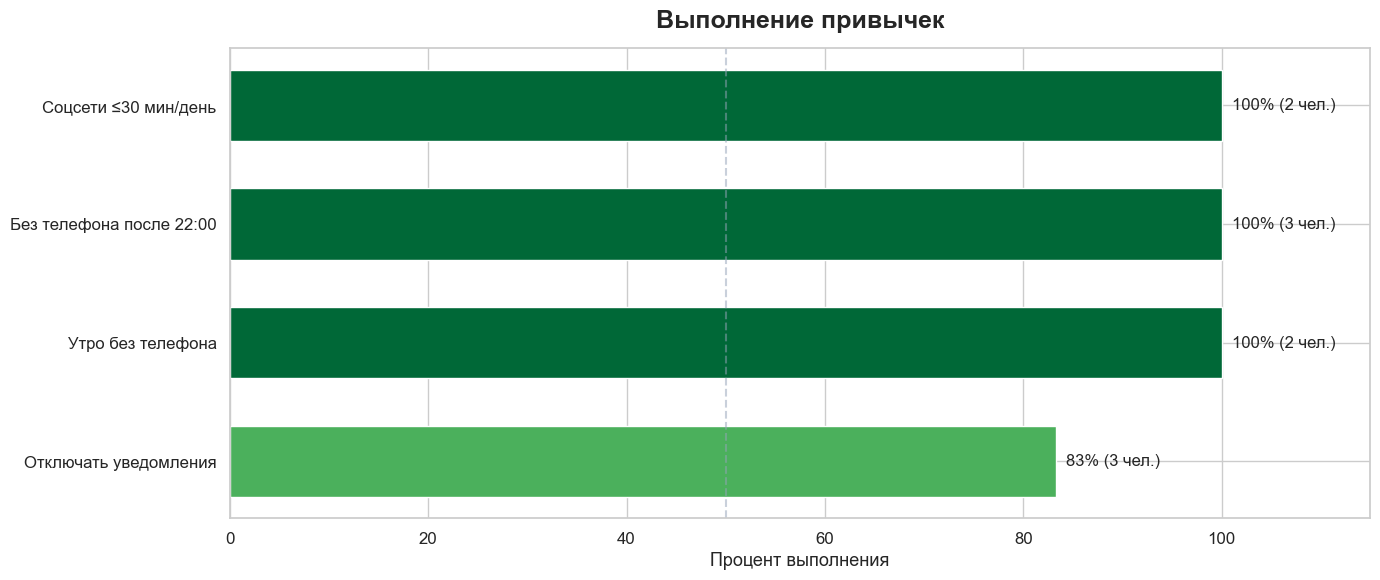

In [12]:
# 7a. Процент выполнения по привычкам
progress['value_bool'] = progress['value'].astype(str).str.lower() == 'true'

# Фильтруем тестовые привычки
real_habits = progress[~progress['habit'].isin(['test2', '905295094204', 'Мяу'])]

habit_completion = real_habits.groupby('habit').agg(
    total=('value_bool', 'count'),
    completed=('value_bool', 'sum'),
    n_users=('user_id', 'nunique'),
).reset_index()
habit_completion['pct'] = (habit_completion['completed'] / habit_completion['total'] * 100).round(1)
habit_completion = habit_completion.sort_values('pct', ascending=True)

# Горизонтальный bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Короткие названия для оси
short_names = {
    'Отключать уведомления во время фокусной работы': 'Отключать уведомления',
    'Начинать утро без телефона': 'Утро без телефона',
    'Не брать телефон в руки после 22:00': 'Без телефона после 22:00',
    'Ограничивать соцсети до 30 минут в день': 'Соцсети ≤30 мин/день',
    'Удалить все соцсети': 'Удалить соцсети',
}

labels = [short_names.get(h, h) for h in habit_completion['habit']]
colors = plt.cm.RdYlGn(habit_completion['pct'] / 100)

bars = ax.barh(labels, habit_completion['pct'], color=colors, edgecolor='white', height=0.6)

for bar, pct, n in zip(bars, habit_completion['pct'], habit_completion['n_users']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{pct:.0f}% ({n} чел.)', va='center', fontsize=12)

ax.set_xlabel('Процент выполнения', fontsize=13)
ax.set_title('Выполнение привычек', fontsize=18, fontweight='bold', pad=15)
ax.set_xlim(0, 115)
ax.axvline(x=50, color='#94a3b8', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

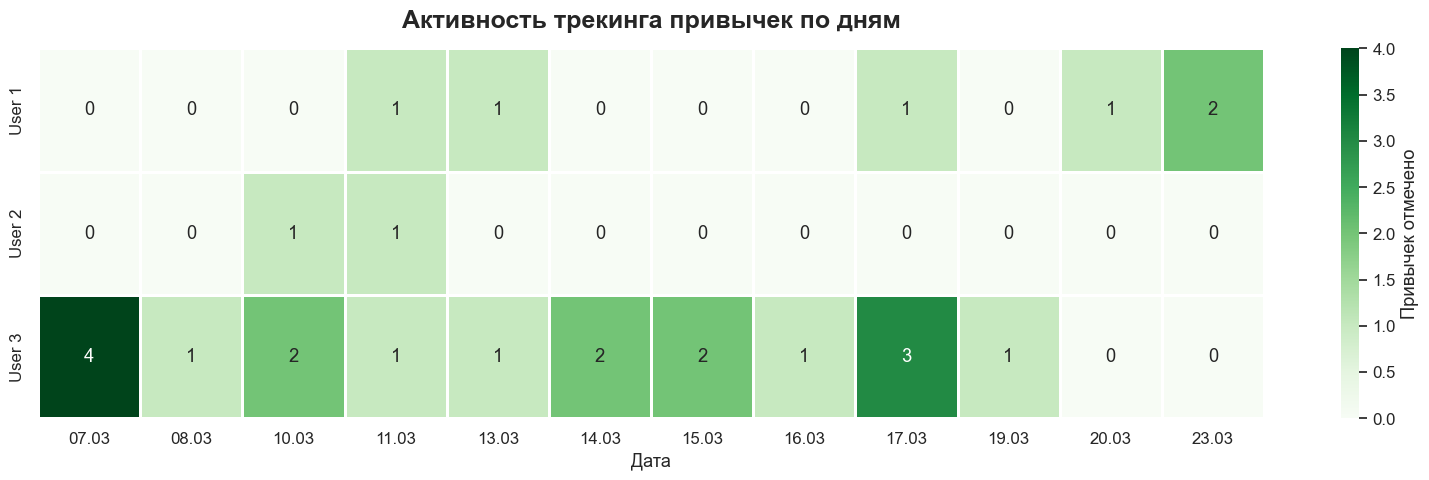

Пользователей с трекингом: 4
Всего отметок привычек: 26
Среднее отметок на пользователя: 6.5


In [13]:
# 7b. Heatmap трекинга привычек по пользователям и дням
real_habits_progress = real_habits.copy()

# date читается как float (12.03), форматируем обратно в строку DD.MM
date_str = real_habits_progress['date'].apply(lambda x: f"{x:.2f}" if isinstance(x, float) else str(x))
real_habits_progress['date_parsed'] = pd.to_datetime(date_str + '.2026', format='%d.%m.%Y')

user_day_counts = real_habits_progress[real_habits_progress['value_bool']].groupby(
    ['user_id', 'date_parsed']
).size().reset_index(name='habits_done')

# Пользователям даём номера
user_ids_tracker = sorted(user_day_counts['user_id'].unique())
user_labels = {uid: f'User {i+1}' for i, uid in enumerate(user_ids_tracker)}
user_day_counts['user_label'] = user_day_counts['user_id'].map(user_labels)

tracker_pivot = user_day_counts.pivot(index='user_label', columns='date_parsed', values='habits_done').fillna(0)
tracker_pivot.columns = [d.strftime('%d.%m') for d in tracker_pivot.columns]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    tracker_pivot, annot=True, fmt='.0f',
    cmap='Greens', linewidths=1, linecolor='white',
    cbar_kws={'label': 'Привычек отмечено'},
    ax=ax,
)
ax.set_title('Активность трекинга привычек по дням', fontsize=18, fontweight='bold', pad=15)
ax.set_xlabel('Дата', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

# Статистика
total_users_tracking = real_habits_progress['user_id'].nunique()
total_checks = real_habits_progress['value_bool'].sum()
print(f"Пользователей с трекингом: {total_users_tracking}")
print(f"Всего отметок привычек: {int(total_checks)}")
print(f"Среднее отметок на пользователя: {total_checks/total_users_tracking:.1f}")

## 8. Анализ авторизации

Соотношение успешных и неуспешных попыток входа и регистрации.

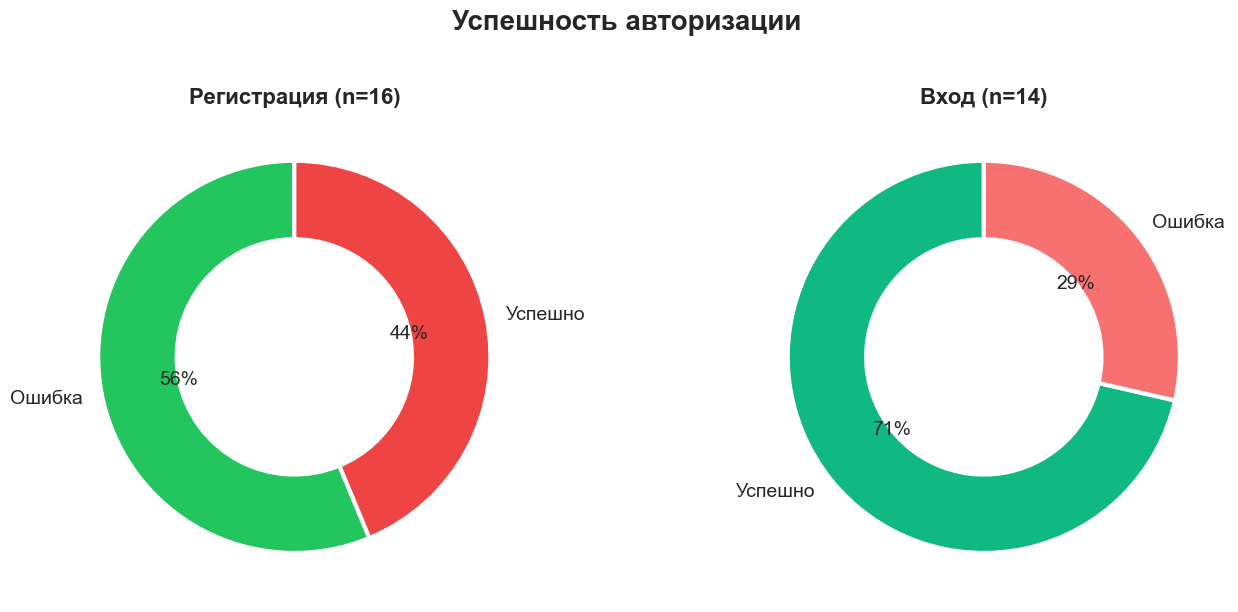

  sign_up_success: 7 событий, 7 пользователей
  sign_up_error: 9 событий, 4 пользователей
  sign_in_success: 10 событий, 7 пользователей
  sign_in_error: 4 событий, 3 пользователей


In [14]:
# 8. Donut charts — авторизация
auth_events = raw_events[raw_events['event'].str.contains('sign')].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sign Up
signup = auth_events[auth_events['event'].str.contains('sign_up')]
signup_counts = signup['event'].value_counts()
colors_signup = ['#22c55e', '#ef4444']
axes[0].pie(
    signup_counts.values,
    labels=['Успешно' if 'success' in l else 'Ошибка' for l in signup_counts.index],
    autopct='%1.0f%%', startangle=90,
    colors=colors_signup,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=14),
)
axes[0].set_title(f'Регистрация (n={signup_counts.sum()})', fontsize=16, fontweight='bold')

# Sign In
signin = auth_events[auth_events['event'].str.contains('sign_in')]
signin_counts = signin['event'].value_counts()
colors_signin = ['#10b981', '#f87171']
axes[1].pie(
    signin_counts.values,
    labels=['Успешно' if 'success' in l else 'Ошибка' for l in signin_counts.index],
    autopct='%1.0f%%', startangle=90,
    colors=colors_signin,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=3),
    textprops=dict(fontsize=14),
)
axes[1].set_title(f'Вход (n={signin_counts.sum()})', fontsize=16, fontweight='bold')

plt.suptitle('Успешность авторизации', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Детали
for evt in ['sign_up_success', 'sign_up_error', 'sign_in_success', 'sign_in_error']:
    n = len(auth_events[auth_events['event'] == evt])
    u = auth_events[auth_events['event'] == evt]['user_id'].nunique()
    print(f"  {evt}: {n} событий, {u} пользователей")

## 9. Сводка — ключевые метрики и выводы

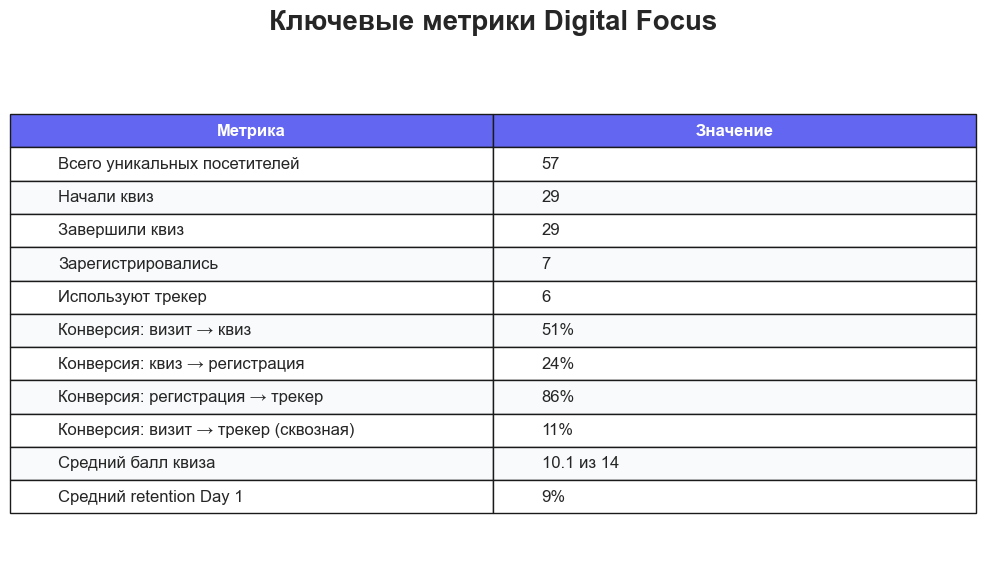

In [15]:
# Сводная таблица ключевых метрик
summary_data = {
    'Метрика': [
        'Всего уникальных посетителей',
        'Начали квиз',
        'Завершили квиз',
        'Зарегистрировались',
        'Используют трекер',
        'Конверсия: визит → квиз',
        'Конверсия: квиз → регистрация',
        'Конверсия: регистрация → трекер',
        'Конверсия: визит → трекер (сквозная)',
        'Средний балл квиза',
        'Средний retention Day 1',
    ],
    'Значение': [
        f"{raw_events['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='quiz_start']['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='quiz_complete']['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='sign_up_success']['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='tracker_view']['user_id'].nunique()}",
        f"{raw_events[raw_events['event']=='quiz_start']['user_id'].nunique() / raw_events['user_id'].nunique() * 100:.0f}%",
        f"{raw_events[raw_events['event']=='sign_up_success']['user_id'].nunique() / max(raw_events[raw_events['event']=='quiz_complete']['user_id'].nunique(), 1) * 100:.0f}%",
        f"{raw_events[raw_events['event']=='tracker_view']['user_id'].nunique() / max(raw_events[raw_events['event']=='sign_up_success']['user_id'].nunique(), 1) * 100:.0f}%",
        f"{raw_events[raw_events['event']=='tracker_view']['user_id'].nunique() / raw_events['user_id'].nunique() * 100:.0f}%",
        f"{last_scores['score'].mean():.1f} из 14",
        f"{avg_retention.get(1, 0):.0f}%",
    ]
}

summary_df = pd.DataFrame(summary_data)

# Визуализация как styled table
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table = ax.table(
    cellText=summary_df.values,
    colLabels=summary_df.columns,
    loc='center',
    cellLoc='left',
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Стилизация заголовков
for j in range(2):
    table[0, j].set_facecolor('#6366f1')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Чередование строк
for i in range(1, len(summary_df) + 1):
    color = '#f8fafc' if i % 2 == 0 else 'white'
    for j in range(2):
        table[i, j].set_facecolor(color)

ax.set_title('Ключевые метрики Digital Focus', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 10. Склейка анонимных и Supabase user_id

Один человек до регистрации фигурирует под анонимным `user_id`, после — под Supabase UUID.
Если последнее анонимное событие пользователя произошло за несколько минут до первого Supabase события,
с высокой вероятностью это один и тот же человек.

In [16]:
supabase_ids = set(users['id'].astype(str))
raw_events['id_type'] = raw_events['user_id'].apply(
    lambda x: 'supabase' if x in supabase_ids else 'anon'
)

reg_first = (raw_events[raw_events['id_type'] == 'supabase']
             .groupby('user_id')['created_at'].min().reset_index()
             .rename(columns={'created_at': 'reg_first_ts'}))

anon_last = (raw_events[raw_events['id_type'] == 'anon']
             .groupby('user_id')['created_at'].max().reset_index()
             .rename(columns={'user_id': 'anon_id', 'created_at': 'anon_last_ts'}))

GLUE_WINDOW = timedelta(minutes=10)

pairs = []
for _, reg in reg_first.iterrows():
    cand = anon_last[
        (anon_last['anon_last_ts'] <= reg['reg_first_ts']) &
        (anon_last['anon_last_ts'] >= reg['reg_first_ts'] - GLUE_WINDOW)
    ]
    if len(cand) >= 1:
        closest = cand.loc[cand['anon_last_ts'].idxmax()]
        pairs.append({
            'anon_id': closest['anon_id'],
            'supabase_id': reg['user_id'],
            'gap_sec': (reg['reg_first_ts'] - closest['anon_last_ts']).total_seconds()
        })

glue_df = pd.DataFrame(pairs)
print(f"Pairs found: {len(glue_df)}")
print(glue_df)

glue_df.to_pickle('glue.pkl')

Pairs found: 4
                                anon_id                           supabase_id  \
0  703af6fc-8a37-4a4b-9d5c-0a78343142b2  003f0c5c-a60d-4ca5-9a5b-9381fa44cc8b   
1  e92e5330-9ca7-4859-b9c6-39d35fb59021  25c20f46-73fb-4104-835f-ff02e180b149   
2  2a92dce0-7677-4ebe-9572-d85ee46403d6  95f8e451-1bc3-4f10-b42b-711f6df89dc5   
3  bb491be8-e47c-465e-b72d-84970ca67ea7  d184b2f1-38c3-4f36-9498-fc32644002e2   

   gap_sec  
0     13.0  
1    148.0  
2     43.0  
3     19.0  


### 10.1. Воронка по `person_id`

Подставляем `person_id` вместо «сырого» `user_id`: для анонимного id, у которого нашлась пара,
используем соответствующий Supabase UUID — так один человек не считается дважды.

In [17]:
glue_df = pd.read_pickle('glue.pkl')
glue_map = dict(zip(glue_df['anon_id'], glue_df['supabase_id']))

raw_events['person_id'] = raw_events['user_id'].map(glue_map).fillna(raw_events['user_id'])

print(f"Old unique user_id: {raw_events['user_id'].nunique()}")
print(f"New unique person_id: {raw_events['person_id'].nunique()}")

funnel = [
    ('Посещение сайта',       raw_events['person_id'].nunique()),
    ('Начало квиза',          raw_events[raw_events['event'] == 'quiz_start']['person_id'].nunique()),
    ('Завершение квиза',      raw_events[raw_events['event'] == 'quiz_complete']['person_id'].nunique()),
    ('Просмотр результата',   raw_events[raw_events['event'] == 'result_view']['person_id'].nunique()),
    ('Просмотр рекомендаций', raw_events[raw_events['event'] == 'recommendations_view']['person_id'].nunique()),
    ('Регистрация',           raw_events[raw_events['event'] == 'sign_up_success']['person_id'].nunique()),
    ('Открытие трекера',      raw_events[raw_events['event'] == 'tracker_view']['person_id'].nunique()),
    ('Добавление привычки',   raw_events[raw_events['event'] == 'habit_add']['person_id'].nunique()),
]
funnel_person_df = pd.DataFrame(funnel, columns=['Этап', 'Уникальных'])
funnel_person_df['% от старта'] = (funnel_person_df['Уникальных'] / funnel_person_df['Уникальных'].iloc[0] * 100).round(1)
funnel_person_df['% от пред.'] = (funnel_person_df['Уникальных'] / funnel_person_df['Уникальных'].shift(1) * 100).round(1)
print(funnel_person_df.to_string(index=False))

Old unique user_id: 57
New unique person_id: 53
                 Этап  Уникальных  % от старта  % от пред.
      Посещение сайта          53        100.0         NaN
         Начало квиза          27         50.9        50.9
     Завершение квиза          27         50.9       100.0
  Просмотр результата          27         50.9       100.0
Просмотр рекомендаций          24         45.3        88.9
          Регистрация           7         13.2        29.2
     Открытие трекера           6         11.3        85.7
  Добавление привычки           4          7.5        66.7


### 10.2. Retention по `person_id`

Считаем, какая доля «склеенных» пользователей вернулась на Day 1, Day 2, Day 4 относительно своего
первого визита. Сохраняем новые версии графиков как `funnel_v2.png` и `metrics_v2.png`.

In [18]:
# Retention по person_id
events_df = raw_events.copy()
events_df['date'] = events_df['created_at'].dt.date
first_day = events_df.groupby('person_id')['date'].min().to_dict()
events_df['days_since_first'] = events_df.apply(
    lambda r: (r['date'] - first_day[r['person_id']]).days, axis=1
)

total_users = events_df['person_id'].nunique()

def _retention(day_n):
    n = events_df[events_df['days_since_first'] == day_n]['person_id'].nunique()
    return n, n / total_users

d1_n, d1 = _retention(1)
d2_n, d2 = _retention(2)
d4_n, d4 = _retention(4)

print(f"Уникальных person_id: {total_users}")
print(f"Retention Day 1: {d1:.1%} ({d1_n}/{total_users})")
print(f"Retention Day 2: {d2:.1%} ({d2_n}/{total_users})")
print(f"Retention Day 4: {d4:.1%} ({d4_n}/{total_users})")

Уникальных person_id: 53
Retention Day 1: 7.5% (4/53)
Retention Day 2: 5.7% (3/53)
Retention Day 4: 3.8% (2/53)


/var/folders/mq/hdkb64ls4fd_fzqmcy2rzpn00000gn/T/ipykernel_59509/1752410789.py:46: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image('funnel_v2.png', width=800, height=500, scale=2)


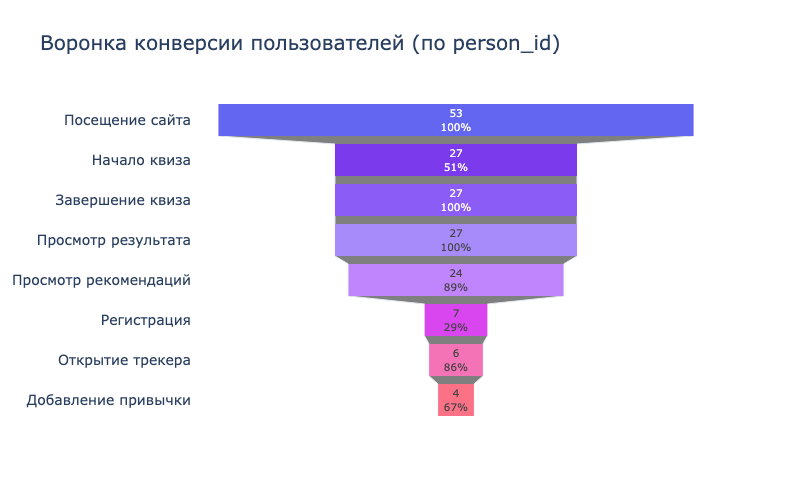


Детализация воронки (person_id):
                 step  users  pct_total  pct_prev
      Посещение сайта     53      100.0     100.0
         Начало квиза     27       50.9      50.9
     Завершение квиза     27       50.9     100.0
  Просмотр результата     27       50.9     100.0
Просмотр рекомендаций     24       45.3      88.9
          Регистрация      7       13.2      29.2
     Открытие трекера      6       11.3      85.7
  Добавление привычки      4        7.5      66.7


In [19]:
# Воронка v2 — по person_id, тот же plotly-стиль, что и в первой воронке.
# Сохраняем в funnel_v2.png (требуется kaleido==0.2.1).
funnel_steps_v2 = [
    ('Посещение сайта',       None),
    ('Начало квиза',          'quiz_start'),
    ('Завершение квиза',      'quiz_complete'),
    ('Просмотр результата',   'result_view'),
    ('Просмотр рекомендаций', 'recommendations_view'),
    ('Регистрация',           'sign_up_success'),
    ('Открытие трекера',      'tracker_view'),
    ('Добавление привычки',   'habit_add'),
]
rows = []
for label, event in funnel_steps_v2:
    n = (raw_events['person_id'].nunique() if event is None
         else raw_events[raw_events['event'] == event]['person_id'].nunique())
    rows.append({'step': label, 'users': n})

funnel_df = pd.DataFrame(rows)
funnel_df['pct_total'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['pct_prev'] = (
    [100.0] +
    (funnel_df['users'].iloc[1:].values /
     funnel_df['users'].iloc[:-1].values * 100).round(1).tolist()
)

fig = go.Figure(go.Funnel(
    y=funnel_df['step'],
    x=funnel_df['users'],
    textinfo='value+percent previous',
    textposition='inside',
    marker=dict(
        color=['#6366f1', '#7c3aed', '#8b5cf6', '#a78bfa',
               '#c084fc', '#d946ef', '#f472b6', '#fb7185'],
    ),
    connector=dict(line=dict(color='#e2e8f0', width=1)),
))

fig.update_layout(
    title=dict(text='Воронка конверсии пользователей (по person_id)', font=dict(size=20)),
    font=dict(size=14),
    height=500,
    width=800,
    plot_bgcolor='white',
)
fig.write_image('funnel_v2.png', width=800, height=500, scale=2)
fig.show()

print("\nДетализация воронки (person_id):")
print(funnel_df.to_string(index=False))

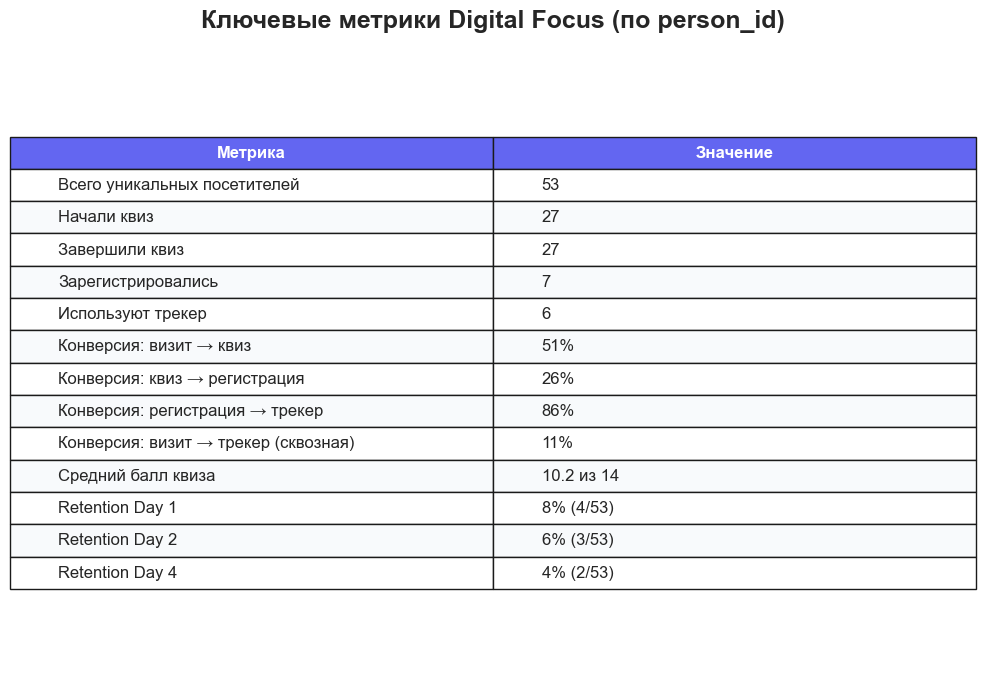

In [20]:
# Сводка метрик v2 — по person_id, сохраняем в metrics_v2.png
def _n(evt):
    return raw_events[raw_events['event'] == evt]['person_id'].nunique()

n_visit   = raw_events['person_id'].nunique()
n_qstart  = _n('quiz_start')
n_qdone   = _n('quiz_complete')
n_signup  = _n('sign_up_success')
n_tracker = _n('tracker_view')

qc = raw_events[raw_events['event'] == 'quiz_complete'].copy()
qc['score'] = qc['params'].apply(lambda x: x.get('score'))
qc = qc.dropna(subset=['score'])
last_scores_v2 = (qc.sort_values('created_at')
                    .groupby('person_id').last().reset_index())
avg_score_v2 = last_scores_v2['score'].astype(int).mean() if len(last_scores_v2) else 0

summary_rows = [
    ('Всего уникальных посетителей',         f'{n_visit}'),
    ('Начали квиз',                          f'{n_qstart}'),
    ('Завершили квиз',                       f'{n_qdone}'),
    ('Зарегистрировались',                   f'{n_signup}'),
    ('Используют трекер',                    f'{n_tracker}'),
    ('Конверсия: визит → квиз',              f'{n_qstart / n_visit * 100:.0f}%'),
    ('Конверсия: квиз → регистрация',        f'{n_signup / max(n_qdone, 1) * 100:.0f}%'),
    ('Конверсия: регистрация → трекер',      f'{n_tracker / max(n_signup, 1) * 100:.0f}%'),
    ('Конверсия: визит → трекер (сквозная)', f'{n_tracker / n_visit * 100:.0f}%'),
    ('Средний балл квиза',                   f'{avg_score_v2:.1f} из 14'),
    ('Retention Day 1',                      f'{d1*100:.0f}% ({d1_n}/{total_users})'),
    ('Retention Day 2',                      f'{d2*100:.0f}% ({d2_n}/{total_users})'),
    ('Retention Day 4',                      f'{d4*100:.0f}% ({d4_n}/{total_users})'),
]
summary_df_v2 = pd.DataFrame(summary_rows, columns=['Метрика', 'Значение'])

fig, ax = plt.subplots(figsize=(10, 7))
ax.axis('off')
table = ax.table(cellText=summary_df_v2.values,
                 colLabels=summary_df_v2.columns,
                 loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.7)

for j in range(2):
    table[0, j].set_facecolor('#6366f1')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(summary_df_v2) + 1):
    color = '#f8fafc' if i % 2 == 0 else 'white'
    for j in range(2):
        table[i, j].set_facecolor(color)

ax.set_title('Ключевые метрики Digital Focus (по person_id)',
             fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('metrics_v2.png', dpi=150, bbox_inches='tight')
plt.show()

### 10.3. Нагрузка, сегменты и связь балла с активностью (по `person_id`)

Используем `events_df` со склеенной колонкой `person_id`. Названия событий взяты из реального датасета
(`quiz_start`, `quiz_complete`, `sign_up_success`, `tracker_view`, `habit_add`). Балл квиза лежит в
`params['score']`.

In [21]:
from scipy.stats import pearsonr

# === БЛОК 1. Распределение по уровням цифровой нагрузки ======================
# Берём последний quiz_complete каждого person_id, балл из params['score'].
qc = events_df[events_df['event'] == 'quiz_complete'].copy()
qc['score'] = qc['params'].apply(lambda p: p.get('score'))
qc = qc.dropna(subset=['score'])
qc['score'] = qc['score'].astype(int)

last_quiz = (qc.sort_values('created_at')
               .groupby('person_id').last()
               .reset_index()[['person_id', 'created_at', 'score']])

def load_level(s):
    if s <= 5:  return 'Низкая (0–5)'
    if s <= 10: return 'Умеренная (6–10)'
    return 'Высокая (11–16)'

last_quiz['level'] = last_quiz['score'].apply(load_level)
n_quiz = len(last_quiz)
level_order = ['Низкая (0–5)', 'Умеренная (6–10)', 'Высокая (11–16)']
load_dist = (last_quiz['level'].value_counts()
             .reindex(level_order, fill_value=0)
             .rename('Пользователей').to_frame())
load_dist['%'] = (load_dist['Пользователей'] / n_quiz * 100).round(1)

print(f"БЛОК 1 — Распределение по уровням цифровой нагрузки (n={n_quiz}):")
print(load_dist.to_string())

# === БЛОК 2. Сегментация (взаимоисключающая) =================================
# Каждый person_id → один сегмент по самой глубокой достигнутой точке воронки.
person_events = events_df.groupby('person_id')['event'].agg(set)

def assign_segment(events):
    if 'habit_add' in events:        return 'Активный пользователь'
    if 'tracker_view' in events:     return 'Открыл трекер'
    if 'sign_up_success' in events:  return 'Зарегистрированный'
    if 'quiz_complete' in events:    return 'Прошёл квиз'
    if 'quiz_start' not in events:   return 'Bounce'
    # запасной случай: начал квиз, но не завершил
    return 'Начал квиз (не завершил)'

segments = person_events.apply(assign_segment)
seg_order = ['Bounce', 'Начал квиз (не завершил)', 'Прошёл квиз',
             'Зарегистрированный', 'Открыл трекер', 'Активный пользователь']
seg_df = (segments.value_counts()
          .reindex(seg_order, fill_value=0)
          .rename('Пользователей').to_frame())
seg_df['%'] = (seg_df['Пользователей'] / seg_df['Пользователей'].sum() * 100).round(1)
seg_df = seg_df[seg_df['Пользователей'] > 0]

print(f"\nБЛОК 2 — Сегментация (сумма должна быть {events_df['person_id'].nunique()}):")
print(seg_df.to_string())
print(f"Итого: {seg_df['Пользователей'].sum()}")

# === БЛОК 3. Корреляция балла квиза с пост-квиз активностью ==================
last_quiz_sorted = last_quiz[['person_id', 'created_at', 'score']].rename(
    columns={'created_at': 'quiz_ts', 'score': 'balls'}
)

# Считаем события строго ПОСЛЕ времени последнего quiz_complete.
events_after = (events_df.merge(last_quiz_sorted, on='person_id')
                          .query('created_at > quiz_ts')
                          .groupby('person_id').size()
                          .rename('events_after_quiz'))
corr_df = last_quiz_sorted.set_index('person_id').join(events_after).fillna(0)
corr_df['events_after_quiz'] = corr_df['events_after_quiz'].astype(int)

r, p_value = pearsonr(corr_df['balls'], corr_df['events_after_quiz'])
print(f"\nБЛОК 3 — Корреляция балла квиза и активности после квиза:")
print(f"  N пользователей: {len(corr_df)}")
print(f"  Pearson r:       {r:.3f}")
print(f"  p-value:         {p_value:.4f}")

БЛОК 1 — Распределение по уровням цифровой нагрузки (n=27):


                  Пользователей     %
level                                
Низкая (0–5)                  1   3.7
Умеренная (6–10)             14  51.9
Высокая (11–16)              12  44.4

БЛОК 2 — Сегментация (сумма должна быть 53):
                       Пользователей     %
event                                     
Bounce                            24  45.3
Прошёл квиз                       18  34.0
Зарегистрированный                 5   9.4
Открыл трекер                      2   3.8
Активный пользователь              4   7.5
Итого: 53

БЛОК 3 — Корреляция балла квиза и активности после квиза:
  N пользователей: 27
  Pearson r:       -0.206
  p-value:         0.3025
